In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('default')

from agent.components import RASK
from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType, theoretical_param_bounds, ServiceVar, FIG_SIZE_DEFAULT
from agent.components.commons import SloSet

services = [ServiceType.QR, ServiceType.CV, ServiceType.PC]
slos = [SloSet.DEFAULT, SloSet.HIGH_PERF, SloSet.LOW_COST, SloSet.HIGH_QUALITY]

## **Monitor**: Service Telemetry

### Justification: How much exploration is needed?

In [2]:
# TODO: Here I can just show the data structure
# TODO: The question is also WHY did I use the 20 exploration round?

df_explore = pd.read_csv("../../statics/agent_experience/metrics_DEMO_EXPLORE.csv")
df_explore_preprocessed = RASK.preprocess_data(df_explore)

INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str


## **Analyze**: Regression Analysis of Structural Knowledge

### Create Structural Knowledge

Purpose is to identify structural dependencies directly from data

Please talk to **Nefeli Marina Rouska** if you find this interesting

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered,O=Categorical Ordered)inferred from data: 
 {'cores': 'N', 'throughput': 'N', 'data_quality': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

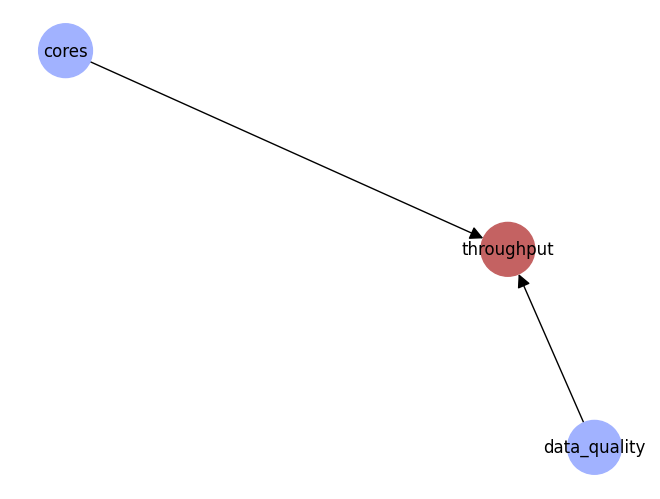

In [3]:
from pgmpy.structure_score import AICGauss
from utils import visualize_DAG

from pgmpy.base import DAG
from pgmpy.causal_discovery import HillClimbSearch

df_filtered = df_explore_preprocessed[df_explore_preprocessed['service_type'] == ServiceType.QR.value]
df_filtered = df_filtered[['cores', 'throughput', 'data_quality']]

scoring_method = AICGauss(data=df_filtered)
estimator = HillClimbSearch(scoring_method=scoring_method)

estimator.fit(X=df_filtered)
dag: DAG = estimator.causal_graph_

regular = '#a1b2ff'  # blue
special = '#c46262'  # red

visualize_DAG(dag, color_map=[regular, special, regular])

### Functional Data Analysis

#### Variant 1: Using a Simple Regression Model

Low complexity

No uncertainty

#### Variant 2: Using a Gaussian Process

Medium complexity

Has uncertainty

In [ ]:
# import plotly.io as pio
#
# print(pio.renderers)
# pio.renderers.default = "chrome"
# import plotly
# import jupyterlab
#
# print(plotly.__version__)
# print(jupyterlab.__version__)

# for type in ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
#          'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
#          'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
#          'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
#          'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']:

In [5]:
# TODO: Give the option to change between interactive plot and not; the static
#  plot would also always render withing the notebook.

import plotly.io as pio

pio.renderers.default = 'browser'

gp_list = []
lml_history = []

split_data_into_x_parts = 10
iterate_through_x_parts = 10

for i in range(iterate_through_x_parts):
    gp_all_services = {}
    data_ratio = (i + 1) / split_data_into_x_parts
    lml_all_service = []

    for s in services:
        # Initialize and train GP model
        draw_figures = i == (iterate_through_x_parts / 2) - 1 or i == iterate_through_x_parts - 1
        _gp = GASK(s, create_figures=draw_figures, display_figures=draw_figures)
        _gp.init_model(df_explore, data_density=data_ratio)

        _lml = _gp.get_model_lml(s, "max_tp")
        lml_scaled = _lml / data_ratio
        lml_all_service.append(lml_scaled)
        # print(f"Ratio {data_ratio}: LML = {lml:.2f}")
        gp_all_services[s] = _gp

    lml_history.append(lml_all_service)
    gp_list.append(gp_all_services)

    print(f"Finished {i + 1} / {iterate_through_x_parts} of the Gaussian Processes")

lml_history = np.array(lml_history)


INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:trai

Finished 1 / 10 of the Gaussian Processes
Finished 2 / 10 of the Gaussian Processes


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound a

Finished 3 / 10 of the Gaussian Processes


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
INFO:multiscale:train_gp_models took 65 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a bette

...

Finished 8 / 10 of the Gaussian Processes


INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-pc-visualizer - Target: max_tp
INFO:multiscale:train_gp_models took 80 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Finished 9 / 10 of the Gaussian Processes


INFO:multiscale:draw_3d_gp_plot took 543 ms to execute
INFO:multiscale:train_gp_models took 639 ms to execute
INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-cv-analyzer - Target: max_tp
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__constant_value is close to the specified lower bound 0.

Finished 10 / 10 of the Gaussian Processes


#### Create LML Figure

In [ ]:
# 1. Define the X-axis (Data Ratios)
data_ratios = np.arange(1, iterate_through_x_parts + 1) / split_data_into_x_parts

# 2. Create the Figure
plt.figure(figsize=FIG_SIZE_DEFAULT)

# Service labels matching your 'services' list order
labels = ['QR Detector', 'CV Analyzer', 'PC Visualizer']
colors = ['#d62728', '#1f77b4', '#2ca02c']  # Red, Blue, Green

for i in range(lml_history.shape[1]):
    plt.plot(data_ratios * (split_data_into_x_parts / iterate_through_x_parts), lml_history[:, i],
             marker='o', markersize=4, linewidth=2,
             label=labels[i], color=colors[i])

# 3. Formatting
abs_samples = int(len(df_explore) * (iterate_through_x_parts / split_data_into_x_parts))
plt.xlabel(f'Ratio of Training Data ({int(abs_samples / 3)} Samples)', fontsize=12)
plt.ylabel('Scaled LML / # Samples', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Service Type")
plt.show()

In [ ]:

RUN_HEATMAP = False  # TODO: Does the heatmap provide some benefit?
if RUN_HEATMAP:

    from agent.components.GaussianProcess import get_empirical_variable_bounds
    from utils import visualize_ndarray
    from agent.components.commons import ServiceVar
    from typing import Dict
    from agent.components.Optimizer import VersatileMapElites


    def extract_pfo_for_SLOs(gp_service, slos: Dict[ServiceVar, float], slo_type: str, simple_bounds):
        v_me = VersatileMapElites(gp_service.s_type, bins=8)

        #  I'm getting the black cells because they are not explored.
        #  What I can do is force all cells to be explored at least once,
        #  or just run gradient descent for each cell multiple (like 5) times.
        v_me.run_search(slos, gp_service, simple_bounds, iterations=2000)
        visualize_ndarray(v_me.fitness_table, gp_service.s_type.value + "_" + slo_type, cmap="viridis")


    final_empirical_bounds = get_empirical_variable_bounds(df_explore_preprocessed)[ServiceType.QR]
    simple_param_bounds = final_empirical_bounds.copy()
    del simple_param_bounds[ServiceVar.PERFORMANCE]
    simple_param_bounds = list(simple_param_bounds.values())

    candidate_solutions = []
    # (1) Here I give it increasingly more training data
    for i in range(iterate_through_x_parts):
        candidates = extract_pfo_for_SLOs(gp_list[i][ServiceType.QR], SloSet.DEFAULT.value, "DEFAULT",
                                          simple_param_bounds)
        candidate_solutions.append(candidates)


## **Plan**: Intent-based Inference

Find optimal parameter configs for each SLO x Service combination after seeing certain data shares

**TODO**: This here could actually be the place where we introduce out multi-dimensional methodology

In [ ]:
from agent.components.Optimizer import run_optimizer_multi

solution_history = []

for i in range(iterate_through_x_parts):
    for q in slos:
        for s in services:
            data_ratio = (i + 1) / iterate_through_x_parts
            gp = gp_list[i][s]

            # Run optimizer to find the best configuration
            solutions = run_optimizer_multi(s, q.value, gp, theoretical_param_bounds[s], runs=25)
            fitness, config = max(solutions, key=lambda x: x[0])

            # Predict performance (mu, sigma) for the chosen configuration
            x_state = {ServiceVar.COST: config[0], ServiceVar.QUALITY: config[1]}
            x_state = x_state | ({ServiceVar.MODEL: config[2]} if s == ServiceType.CV else {})
            mu, sigma = gp.predict(s, "max_tp", x_state)

            # Store everything needed for the next block
            # We include empirical_var_bounds here as it changes per iteration
            solution_history.append({
                'data_rate': data_ratio,
                'rep': None,
                'service_type': s.value,
                'slo_set': q.name,
                'p_fitness': fitness,
                'dist': (mu, sigma),
                'cores': x_state[ServiceVar.COST],
                'data_quality': x_state[ServiceVar.QUALITY],
                'model_size': x_state[ServiceVar.MODEL] if s == ServiceType.CV else -1,
            })

            print(f"Optimal fitness for {s.value} and {q.name} with {data_ratio * 100}% training data: {fitness}")

#### Export to candidate solution script, with each config repeated x times

In [ ]:

repeatable_data = []
runs_per_config = 50

# Iterate through the list in steps of 3 (the size of your service triple)
for i in range(0, len(solution_history), 3):
    # Extract the current triple of rows
    triple = solution_history[i: i + 3]

    # Repeat this specific triple for the number of runs
    for run_idx in range(runs_per_config):
        for row in triple:
            new_row = row.copy()
            new_row['rep'] = run_idx + 1
            repeatable_data.append(new_row)

df_candidates = pd.DataFrame(repeatable_data)
df_candidates.to_csv(
    f'../statics/candidates/candidate_solutions_{iterate_through_x_parts}_{split_data_into_x_parts}_{runs_per_config}.csv',
    index=False)


## **Execute**: Service Scaling

**TODO**: This part would be totally simulated again. The thing is that here we would need some feedback loop. So that the action we take is actually reflected. But the agent experience should feature that? Or in particular the TSC submission. But this means I would also need to use the exploration data from there.